In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

plt.style.use("ggplot")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving master_dataset_final_clean.csv to master_dataset_final_clean.csv
Saving scaled_dataset_v2.csv to scaled_dataset_v2.csv
Saving ml_dataset_v2.csv to ml_dataset_v2.csv


In [21]:
# Features used for clustering

FEATURE_COLUMNS = [

    "literacy_rate_pct",

    "urban_pct",

    "pop_density_per_sq_km",

    "gsdp_growth_current_pct_2022_23",

    "unemp_rate_2023_24",

    "youth_pct_of_population",

    "pmkvy_rate_per_lakh_youth"

]

In [ ]:
ml_df = pd.read_csv("ml_dataset_v2.csv")

scaled_df = pd.read_csv("scaled_dataset_v2.csv")

master_df = pd.read_csv("master_dataset_final_clean.csv")

In [ ]:
print("ML Dataset Shape:", ml_df.shape)
print("Scaled Dataset Shape:", scaled_df.shape)
print("Master Dataset Shape:", master_df.shape)

print("\nMissing Values:")
print(ml_df.isnull().sum())

display(ml_df.head())

ML Dataset Shape: (15, 8)
Scaled Dataset Shape: (15, 8)
Master Dataset Shape: (15, 22)

Missing Values:
state_name                         0
literacy_rate_pct                  0
urban_pct                          0
pop_density_per_sq_km              0
gsdp_growth_current_pct_2022_23    0
unemp_rate_2023_24                 0
youth_pct_of_population            0
pmkvy_rate_per_lakh_youth          0
dtype: int64


,state_name,literacy_rate_pct,urban_pct,pop_density_per_sq_km,gsdp_growth_current_pct_2022_23,unemp_rate_2023_24,youth_pct_of_population,pmkvy_rate_per_lakh_youth
0,Uttar Pradesh,67.68,0.2227,828.0,16.8,3.0,27.63,129.59
1,Maharashtra,82.34,0.4522,365.0,13.5,3.3,28.36,110.64
2,Bihar,61.80,0.1129,1102.0,15.0,3.0,24.22,93.55
3,West Bengal,76.26,0.3187,1029.0,14.0,2.6,28.28,99.81
4,Madhya Pradesh,69.32,0.2763,236.0,16.4,0.9,27.49,174.50


In [22]:
X = scaled_df[FEATURE_COLUMNS]

display(X.head())

,literacy_rate_pct,urban_pct,pop_density_per_sq_km,gsdp_growth_current_pct_2022_23,unemp_rate_2023_24,youth_pct_of_population,pmkvy_rate_per_lakh_youth
0,-0.678647,-0.744196,1.125932,0.476137,-0.161626,0.230639,-0.297311
1,1.160801,1.062882,-0.462771,-1.295952,0.034946,0.720076,-0.519631
2,-1.416433,-1.608759,2.066114,-0.490457,-0.161626,-2.055637,-0.720129
3,0.397920,0.011706,1.815628,-1.027454,-0.423722,0.666439,-0.646687
4,-0.472869,-0.322151,-0.905412,0.261338,-1.537631,0.136774,0.229570


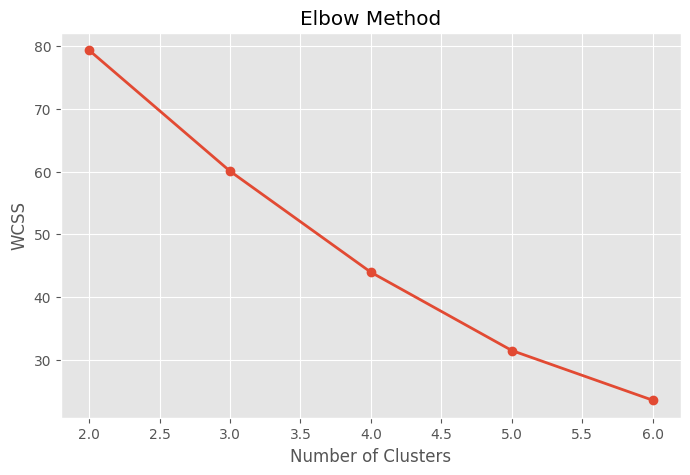

In [ ]:
wcss = []

for k in range(2,7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,7),wcss,marker="o",linewidth=2)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [ ]:
results = []

for k in range(2,7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X,labels)

    results.append([k,score])

    print(f"K = {k}  -->  Silhouette Score = {score:.4f}")

results_df = pd.DataFrame(results,columns=["K","Silhouette Score"])

display(results_df)

K = 2  -->  Silhouette Score = 0.3903
K = 3  -->  Silhouette Score = 0.1774
K = 4  -->  Silhouette Score = 0.2026
K = 5  -->  Silhouette Score = 0.1987
K = 6  -->  Silhouette Score = 0.1970


,K,Silhouette Score
0,2,0.390345
1,3,0.177398
2,4,0.202562
3,5,0.198652
4,6,0.197012


In [ ]:
from sklearn.cluster import KMeans

for k in [2,3,4]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    print("\n")
    print("="*40)

    print(f"K = {k}")

    cluster_counts = pd.Series(labels).value_counts().sort_index()

    print(cluster_counts)



K = 2
0     1
1    14
Name: count, dtype: int64


K = 3
0     1
1    10
2     4
Name: count, dtype: int64


K = 4
0    1
1    7
2    3
3    4
Name: count, dtype: int64


In [ ]:
# Final Cluster Selection

#The Elbow Method and Silhouette Score were evaluated for K = 2 to K = 6.

#Although K = 2 achieved the highest Silhouette Score (0.3903), it produced only two highly imbalanced clusters (14 states and 1 state), which is not suitable for personalized outreach.

#K = 4 was selected because:

#- It creates more meaningful and actionable state segments.
#- It supports the internship objective of designing different AI-driven outreach strategies.
#- It correctly identifies Kerala as a statistically distinct outlier while producing three additional useful clusters for intervention planning.

#Therefore, K = 4 was chosen as the final clustering solution.
# Final KMeans Model

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

kmeans.fit(X)

print("Final KMeans model trained successfully!")

Final KMeans model trained successfully!


In [ ]:
# Assign clusters to each state

ml_df["Cluster"] = kmeans.labels_

display(ml_df[["state_name", "Cluster"]])

,state_name,Cluster
0,Uttar Pradesh,3
1,Maharashtra,2
2,Bihar,3
3,West Bengal,3
4,Madhya Pradesh,1
5,Tamil Nadu,2
6,Rajasthan,1
7,Karnataka,2
8,Gujarat,1
9,Andhra Pradesh,1


In [ ]:
print("Cluster Distribution")

print(ml_df["Cluster"].value_counts().sort_index())

Cluster Distribution
Cluster
0    1
1    7
2    3
3    4
Name: count, dtype: int64


In [ ]:
cluster_summary = ml_df.groupby("Cluster").mean(numeric_only=True)

display(cluster_summary)

,literacy_rate_pct,urban_pct,pop_density_per_sq_km,gsdp_growth_current_pct_2022_23,unemp_rate_2023_24,youth_pct_of_population,pmkvy_rate_per_lakh_youth
Cluster,,,,,,,
0,94.000000,0.477000,859.000000,17.600000,7.200000,23.590000,111.690000
1,70.341429,0.277486,289.571429,17.114286,3.157143,27.885714,203.588571
2,79.263333,0.481333,413.000000,13.800000,3.166667,28.013333,120.983333
3,68.037500,0.223700,843.250000,14.975000,2.475000,26.615000,106.055000


In [ ]:
for cluster in sorted(ml_df["Cluster"].unique()):

    print("=" * 50)
    print(f"Cluster {cluster}")
    print("=" * 50)

    states = ml_df.loc[
        ml_df["Cluster"] == cluster,
        "state_name"
    ].tolist()

    print(states)
    print()

Cluster 0
['Kerala']

Cluster 1
['Madhya Pradesh', 'Rajasthan', 'Gujarat', 'Andhra Pradesh', 'Odisha', 'Telangana', 'Assam']

Cluster 2
['Maharashtra', 'Tamil Nadu', 'Karnataka']

Cluster 3
['Uttar Pradesh', 'Bihar', 'West Bengal', 'Jharkhand']



In [14]:
# Merge cluster labels with master dataset

final_df = master_df.merge(
    ml_df[["state_name", "Cluster"]],
    on="state_name",
    how="left"
)

display(final_df.head())

,state_name,area_sq_km,total_population,decadal_growth_rate,rural_population,rural_pct,urban_population,urban_pct,pop_density_per_sq_km,sex_ratio,...,unemp_rate_2023_24,youth_15_29_total,youth_15_29_male,youth_15_29_female,youth_15_29_rural,youth_15_29_urban,youth_pct_of_population,pmkvy_trained_2023_24,pmkvy_rate_per_lakh_youth,Cluster
0,Uttar Pradesh,240928,199812341,0.202,155317278,0.7773,44495063,0.2227,828.0,912,...,3.0,55198857,29179425,26019432,41628857,13570000,27.63,71530,129.59,3
1,Maharashtra,307713,112374333,0.160,61556074,0.5478,50818259,0.4522,365.0,929,...,3.3,31865346,16828074,15037272,16769787,15095559,28.36,35257,110.64,2
2,Bihar,94163,104099452,0.254,92341436,0.8871,11758016,0.1129,1102.0,918,...,3.0,25209135,13329853,11879282,21977470,3231665,24.22,23583,93.55,3
3,West Bengal,88752,91276115,0.138,62183113,0.6813,29093002,0.3187,1029.0,953,...,2.6,25814262,13169859,12644403,17840412,7973850,28.28,25766,99.81,3
4,Madhya Pradesh,308245,72626809,0.163,52557404,0.7237,20069405,0.2763,236.0,931,...,0.9,19961874,10522485,9439389,14029337,5932537,27.49,34833,174.50,1


In [15]:
# Save clustered master dataset

final_df.to_csv(
    "clustered_states_final_new.csv",
    index=False
)

print("✅ clustered_states_final_new.csv saved successfully.")

✅ clustered_states_final_new.csv saved successfully.


In [16]:
# Save trained KMeans model

joblib.dump(
    kmeans,
    "kmeans_model_new.pkl"
)

print("✅ kmeans_model_new.pkl saved successfully.")

✅ kmeans_model_new.pkl saved successfully.


In [23]:
from sklearn.preprocessing import StandardScaler

# Columns used for clustering
feature_columns = [
    "literacy_rate_pct",
    "urban_pct",
    "pop_density_per_sq_km",
    "gsdp_growth_current_pct_2022_23",
    "unemp_rate_2023_24",
    "youth_pct_of_population",
    "pmkvy_rate_per_lakh_youth"
]

# Create scaler
scaler = StandardScaler()

# Fit scaler on the original ML dataset
scaler.fit(

    ml_df[FEATURE_COLUMNS]

)

# Save scaler
joblib.dump(scaler, "scaler_new.pkl")

print("✅ scaler_new.pkl saved successfully.")

✅ scaler_new.pkl saved successfully.


In [19]:
import os

files = [
    "clustered_states_final_new.csv",
    "kmeans_model_new.pkl",
    "scaler_new.pkl"
]

print("=" * 60)
print("Generated Project Files")
print("=" * 60)

for file in files:
    if os.path.exists(file):
        print(f"✅ {file}")
    else:
        print(f"❌ {file} not found")

Generated Project Files
✅ clustered_states_final_new.csv
✅ kmeans_model_new.pkl
✅ scaler_new.pkl


In [20]:
from google.colab import files

files.download("clustered_states_final_new.csv")
files.download("kmeans_model_new.pkl")
files.download("scaler_new.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>